# 03. Exploratory analysis: demand

What comes in, when, and through which door. Figures are saved to `reports/figures/`.

In [1]:
import json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, Normalize

from denver311 import DUCKDB_PATH, PROCESSED_DIR, RAW_DIR
from denver311 import style
from denver311.style import NAVY, TEAL, BLUE, SLATE, LIGHT, INK

style.apply()
pd.set_option("display.max_columns", 40, "display.width", 160)
con = duckdb.connect(str(DUCKDB_PATH), read_only=True)
q = lambda sql: con.sql(sql).df()

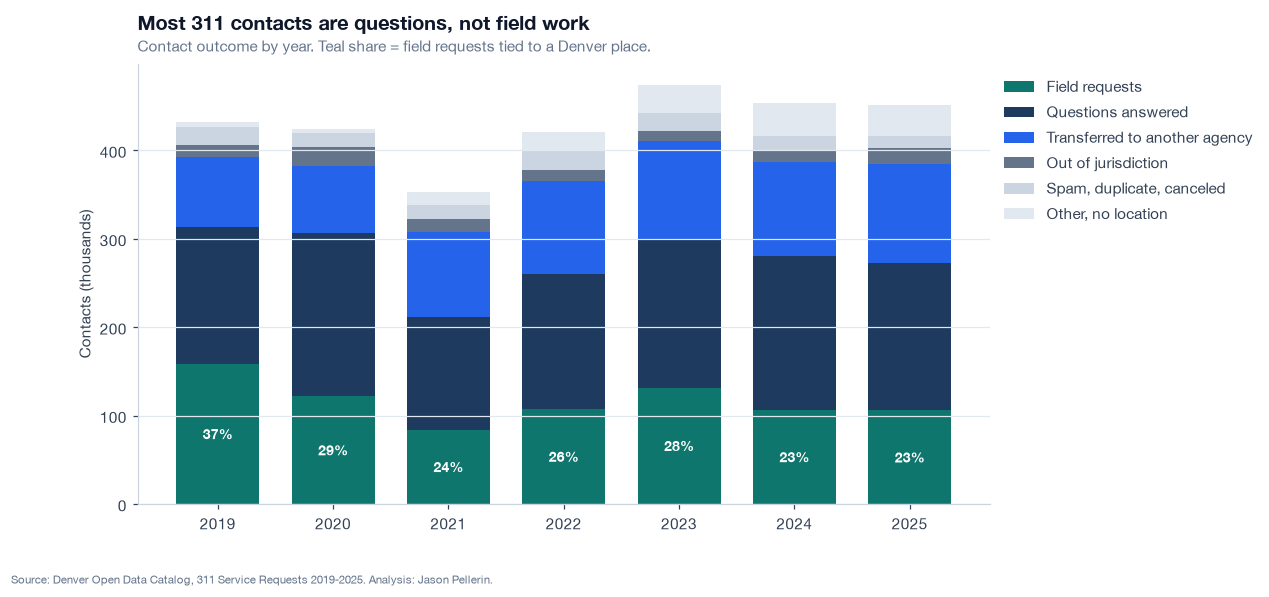

In [2]:
y = q("SELECT * FROM agg_yearly ORDER BY year")
y["other_no_location"] = y.contacts - y[["field_requests", "answered_information", "transferred_out", "out_of_jurisdiction", "invalid"]].sum(axis=1)
parts = [
    ("field_requests", "Field requests", TEAL),
    ("answered_information", "Questions answered", NAVY),
    ("transferred_out", "Transferred to another agency", BLUE),
    ("out_of_jurisdiction", "Out of jurisdiction", SLATE),
    ("invalid", "Spam, duplicate, canceled", LIGHT),
    ("other_no_location", "Other, no location", "#e2e8f0"),
]
fig, ax = plt.subplots(figsize=(10, 5.2))
bottom = np.zeros(len(y))
for col, label, color in parts:
    ax.bar(y.year, y[col] / 1000, bottom=bottom, color=color, label=label, width=0.72)
    bottom += y[col] / 1000
for x, f, t in zip(y.year, y.field_requests, y.contacts):
    ax.text(x, f / 2000, f"{f / t:.0%}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
ax.set_ylabel("Contacts (thousands)")
ax.set_title("Most 311 contacts are questions, not field work", pad=22)
style.subtitle(ax, "Contact outcome by year. Teal share = field requests tied to a Denver place.")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(axis="x", visible=False)
style.save(fig, "fig01_contact_mix");

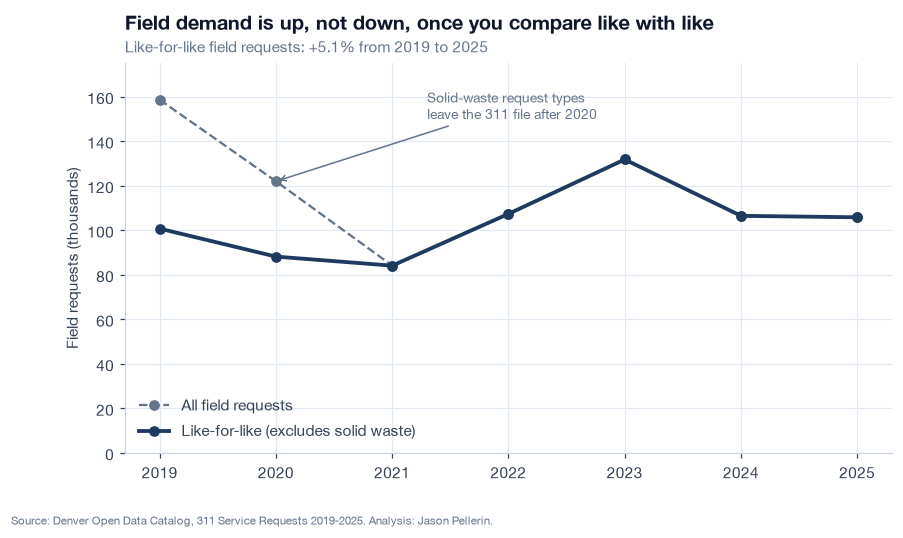

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(y.year, y.field_requests / 1000, color=SLATE, ls="--", marker="o", label="All field requests")
ax.plot(y.year, y.field_requests_like_for_like / 1000, color=NAVY, lw=2.5, marker="o", label="Like-for-like (excludes solid waste)")
ax.annotate("Solid-waste request types\nleave the 311 file after 2020", xy=(2020, y.field_requests[1] / 1000),
            xytext=(2021.3, 150), color=SLATE, fontsize=9, arrowprops=dict(arrowstyle="->", color=SLATE))
change = y.field_requests_like_for_like.iloc[-1] / y.field_requests_like_for_like.iloc[0] - 1
ax.set_ylim(0, 175)
ax.set_ylabel("Field requests (thousands)")
ax.set_title("Field demand is up, not down, once you compare like with like", pad=22)
style.subtitle(ax, f"Like-for-like field requests: {change:+.1%} from 2019 to 2025")
ax.legend(loc="lower left")
style.save(fig, "fig02_field_volume_like_for_like");

In [4]:
q("SELECT year, request_category, field_requests FROM agg_category_year WHERE year IN (2019, 2022, 2025) AND field_requests > 1000 ORDER BY request_category, year").pivot(index="request_category", columns="year", values="field_requests")

year,2019,2022,2025
request_category,,,
Animals,10128.0,1935.0,1731.0
"Clerk, DMV & Elections",1920.0,1108.0,NaN
Encampments,NaN,23687.0,NaN
General Information,11171.0,9547.0,5453.0
Licensing & Permits,8118.0,8546.0,9128.0
Neighborhood Inspection,22644.0,16937.0,16673.0
Parking & Vehicles,9091.0,6734.0,7209.0
Parks & Trees,2901.0,3126.0,1882.0
Public Health & Noise,7378.0,3813.0,3677.0


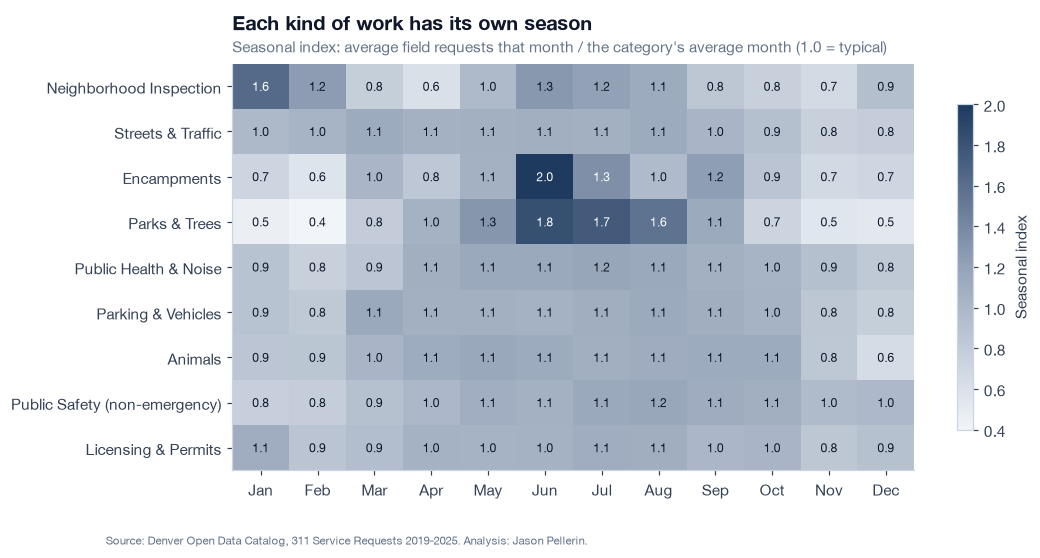

In [5]:
s = q("SELECT * FROM agg_seasonality")
keep = ["Neighborhood Inspection", "Streets & Traffic", "Encampments", "Parks & Trees", "Public Health & Noise", "Parking & Vehicles", "Animals", "Public Safety (non-emergency)", "Licensing & Permits"]
grid = s[s.request_category.isin(keep)].pivot(index="request_category", columns="month_of_year", values="seasonal_index").loc[keep]
fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(grid.values, cmap=style.SEQUENTIAL, aspect="auto", vmin=0.4, vmax=2.0)
ax.set_xticks(range(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_yticks(range(len(keep)), keep)
for i in range(grid.shape[0]):
    for j in range(12):
        v = grid.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8, color="white" if v > 1.3 else INK)
ax.grid(False)
ax.set_title("Each kind of work has its own season", pad=22)
style.subtitle(ax, "Seasonal index: average field requests that month / the category's average month (1.0 = typical)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Seasonal index")
style.save(fig, "fig03_seasonality");

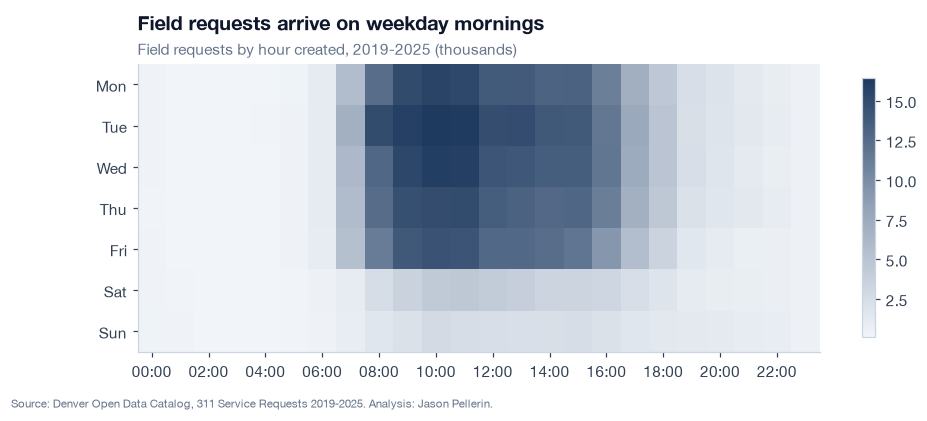

In [6]:
h = q("SELECT * FROM agg_hour_dow").pivot(index="dow", columns="hour", values="field_requests")
fig, ax = plt.subplots(figsize=(10, 3.4))
im = ax.imshow(h.values / 1000, cmap=style.SEQUENTIAL, aspect="auto")
ax.set_yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_xticks(range(0, 24, 2), [f"{x:02d}:00" for x in range(0, 24, 2)])
ax.grid(False)
ax.set_title("Field requests arrive on weekday mornings", pad=22)
style.subtitle(ax, "Field requests by hour created, 2019-2025 (thousands)")
fig.colorbar(im, ax=ax, shrink=0.9)
style.save(fig, "fig04_week_heatmap");

## How long does a 311 case stay open?

Time to close is the gap between the created and closed timestamps on the 311 record. On a log
scale the shape is informative: some types close in a tight band, others split into cases
closed within the hour and cases left open for weeks.

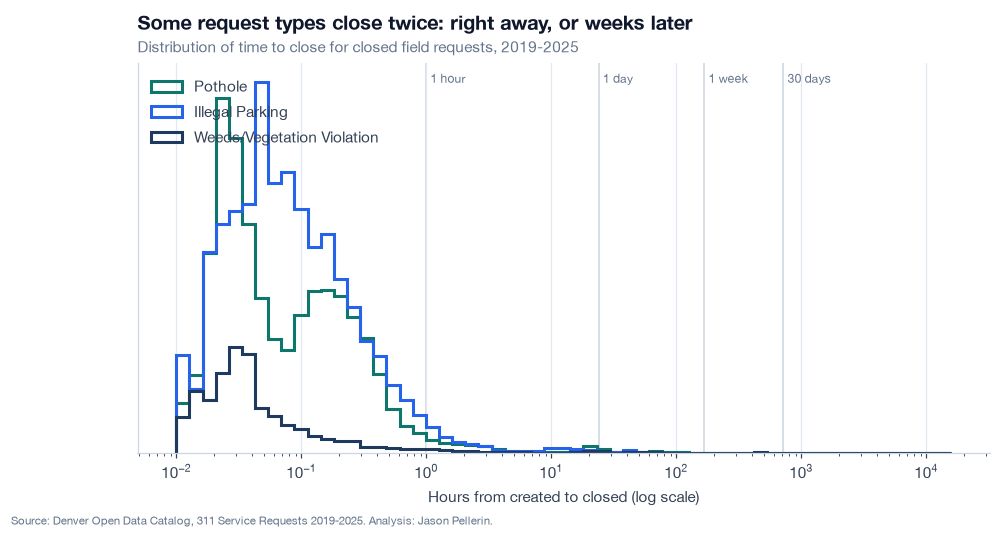

In [7]:
d = q('''
SELECT request_type, hours_to_close FROM field_closed
WHERE request_type IN ('Pothole', 'Illegal Parking', 'Weeds/Vegetation Violation') AND hours_to_close > 0
''')
bins = np.logspace(-2, 4.2, 60)
fig, ax = plt.subplots(figsize=(10, 4.6))
for t, color in [("Pothole", TEAL), ("Illegal Parking", BLUE), ("Weeds/Vegetation Violation", NAVY)]:
    ax.hist(d[d.request_type == t].hours_to_close, bins=bins, histtype="step", lw=2, color=color, label=t, density=True)
ax.set_xscale("log")
for x, lab in [(1, "1 hour"), (24, "1 day"), (24 * 7, "1 week"), (24 * 30, "30 days")]:
    ax.axvline(x, color=LIGHT, lw=1, zorder=0)
    ax.text(x * 1.08, ax.get_ylim()[1] * 0.95, lab, fontsize=8, color=SLATE)
ax.set_xlabel("Hours from created to closed (log scale)")
ax.set_yticks([])
ax.set_title("Some request types close twice: right away, or weeks later", pad=22)
style.subtitle(ax, "Distribution of time to close for closed field requests, 2019-2025")
ax.legend(loc="upper left")
style.save(fig, "fig05_close_time_distribution");

In [8]:
q("SELECT request_type, requests_total, round(share_closed_within_1h, 3) AS within_1h, round(share_closed_after_30d, 3) AS after_30d FROM agg_type_summary ORDER BY within_1h * after_30d DESC LIMIT 8")

,request_type,requests_total,within_1h,after_30d
0,Illegal Parking,7812,0.318,0.132
1,Inquiry,3776,0.067,0.306
2,Other,18214,0.152,0.112
3,Trash in Yard Violation,6318,0.055,0.309
4,ROWE - 72 Hour Enforcement,7499,0.236,0.060
5,Signal Timing,3822,0.057,0.229
6,Callback Request,4194,0.180,0.064
7,Signal Hazard (Traffic),4148,0.246,0.046


Illegal parking is the clearest split: about a third of closed cases close within an hour
and 13% take more than 30 days. Two very different processes share one label, and a single
median hides both.

**Next:** `04_findings.ipynb`.